In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")


In [2]:
# %run C:\Users\user\Downloads\Kafka\Consumer.ipynb

In [3]:
# name = "transactions"

In [4]:
# data=consume_and_process(name)
# data

In [5]:
data = pd.read_csv("transactions.csv")
data

,transaction_id,date,type,amount,currency,country,description,recipient_name
0,3cb7ab06-2125-4faa-9d58-83f7da3bcc40,06/08/2023,payment,14115954.0,CUC,San Marino,utilize efficient convergence,Tonya Jackson
1,a108c0f6-f2b6-4ec5-a319-213f9f093c69,10/06/2024,deposit,25223887.0,BHD,Korea,extend distributed models,Dale Peters
2,dcf4dcf8-f668-4dd9-abb1-1be556a696b0,09/09/2024,deposit,17192978.0,ZWD,Grenada,productize clicks-and-mortar architectures,Jesse Brown
3,b71cfc94-e4dd-4425-bb67-4b7efddb37f3,03/08/2024,transfer,79258418.0,BMD,Palestinian Territory,redefine e-business action-items,Joel Taylor
4,ad42e726-e7e1-4fc4-badd-c177547e7556,03/03/2024,withdrawal,36135677.0,BWP,Niger,transform compelling e-tailers,Denise Jimenez
...,...,...,...,...,...,...,...,...
10195,1f767194-ca25-4e80-99a1-38d7033da849,09/10/2023,payment,22663191.0,EGP,Guam,visualize innovative paradigms,Patty White
10196,f9b334e4-804e-42ef-ae93-1fbc64c94a5f,17/04/2024,transfer,3610955.0,XAF,Bahamas,reinvent customized mindshare,Stephanie Mitchell
10197,3589ac69-9e6d-4ce5-abf0-d4c3f837df03,13/11/2023,transfer,14576639.0,TZS,United States of America,visualize visionary e-business,Christina Price
10198,bfa90f4e-702c-45e7-9dfb-dfb179b885b0,04/05/2023,withdrawal,69018856.0,HUF,United States Minor Outlying Islands,leverage revolutionary action-items,Douglas Campbell


In [6]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  10200 non-null  object 
 1   date            10200 non-null  object 
 2   type            10200 non-null  object 
 3   amount          10200 non-null  float64
 4   currency        10200 non-null  object 
 5   country         10200 non-null  object 
 6   description     10200 non-null  object 
 7   recipient_name  10200 non-null  object 
dtypes: float64(1), object(7)
memory usage: 637.6+ KB


In [7]:
data['date'] = pd.to_datetime(data['date'])

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  10200 non-null  object        
 1   date            10200 non-null  datetime64[ns]
 2   type            10200 non-null  object        
 3   amount          10200 non-null  float64       
 4   currency        10200 non-null  object        
 5   country         10200 non-null  object        
 6   description     10200 non-null  object        
 7   recipient_name  10200 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 637.6+ KB


In [9]:
data.isnull().sum()

transaction_id    0
date              0
type              0
amount            0
currency          0
country           0
description       0
recipient_name    0
dtype: int64

In [10]:
data['amount'].describe()

count    1.020000e+04
mean     5.001850e+07
std      2.879948e+07
min      1.070240e+05
25%      2.522369e+07
50%      4.986985e+07
75%      7.507098e+07
max      9.993262e+07
Name: amount, dtype: float64

In [11]:
data.duplicated().sum()

0

In [12]:
data['country'].nunique()

243

In [13]:
data['currency'].unique()

array(['CUC', 'BHD', 'ZWD', 'BMD', 'BWP', 'RON', 'ISK', 'GEL', 'GYD',
       'KES', 'MRO', 'MVR', 'KRW', 'COP', 'KGS', 'AED', 'TJS', 'INR',
       'HNL', 'PKR', 'MOP', 'VUV', 'XAF', 'LBP', 'CHF', 'FJD', 'DJF',
       'XPF', 'TZS', 'SBD', 'SOS', 'YER', 'HTG', 'LKR', 'TMT', 'PEN',
       'IDR', 'BSD', 'NZD', 'TVD', 'USD', 'NAD', 'ALL', 'UGX', 'XOF',
       'PLN', 'TND', 'EUR', 'OMR', 'KHR', 'BYR', 'MXN', 'BZD', 'ZMW',
       'ILS', 'MMK', 'AUD', 'TWD', 'WST', 'HUF', 'EGP', 'BTN', 'KPW',
       'NOK', 'PYG', 'MGA', 'ERN', 'UAH', 'UZS', 'CDF', 'DZD', 'ARS'],
      dtype=object)

In [14]:
data['currency'].nunique()

72

In [15]:
exchange_rates = pd.DataFrame({
    'currency': ['COP', 'ILS', 'MMK', 'GEL', 'BYR', 'TMT', 'LBP', 'ALL', 'TZS', 'MVR', 
                 'AUD', 'BTN', 'YER', 'TWD', 'TND', 'BMD', 'KES', 'CUC', 'EGP', 'MOP', 'BZD', 
                 'PKR', 'UGX', 'EUR', 'MGA', 'TJS', 'KGS', 'HNL', 'USD', 'NZD', 'IDR', 'XAF', 
                 'INR', 'KRW', 'VUV', 'ISK', 'DZD', 'HTG', 'OMR', 'FJD', 'LKR', 'SOS', 'WST', 
                 'TVD', 'MXN', 'BHD', 'PLN', 'UAH', 'NAD', 'BWP', 'CHF', 'PYG', 'GYD', 'XOF',
                 'XPF', 'RON', 'ERN', 'SBD', 'ZWD', 'AED', 'UZS', 'MRO', 'PEN', 'CDF', 'KPW',
                 'ARS', 'ZMW', 'KHR', 'DJF', 'BSD', 'HUF', 'NOK'],
    'Rate': [0.00021, 0.28, 0.000006, 0.31, 0.00004, 0.28, 0.00006, 0.007, 0.0004, 0.06, 0.67,
             0.007, 0.0004, 0.03, 0.31, 1, 0.0009, 1, 0.03, 0.12, 0.5, 0.004, 0.0002, 0.92, 
             0.0002, 0.1, 0.01, 0.4, 1, 0.61, 0.00007, 0.0017, 0.012, 0.0007, 0.008, 0.007, 
             0.007, 0.007, 2.6, 0.49, 0.004, 0.0006, 0.03, 0.008, 0.05, 2.65, 0.22, 0.02, 0.06,
             0.08, 0.89, 0.00001, 0.0004, 0.0017, 0.0008, 0.21, 0.005, 0.11, 0.00000000004, 0.27,
             0.00009, 0.00002, 0.27, 0.00004, 0.00008, 0.0016, 0.003, 0.0002, 0.005, 1, 0.002, 0.09]
})

In [16]:
exchange_rates

,currency,Rate
0,COP,0.000210
1,ILS,0.280000
2,MMK,0.000006
3,GEL,0.310000
4,BYR,0.000040
...,...,...
67,KHR,0.000200
68,DJF,0.005000
69,BSD,1.000000
70,HUF,0.002000


In [17]:
exchange_rates.loc[exchange_rates['currency']=="USD"]

,currency,Rate
28,USD,1.0


In [18]:
data = data.merge(exchange_rates, on='currency')

In [19]:
data

,transaction_id,date,type,amount,currency,country,description,recipient_name,Rate
0,3cb7ab06-2125-4faa-9d58-83f7da3bcc40,2023-06-08,payment,14115954.0,CUC,San Marino,utilize efficient convergence,Tonya Jackson,1.0000
1,d78a9c72-7700-4724-bc16-4aec42d0bdcd,2024-02-28,withdrawal,7490501.0,CUC,Dominican Republic,mesh best-of-breed paradigms,Jose Mathews,1.0000
2,3382df72-ca6b-455a-8323-67a530fc11c7,2024-07-17,payment,84307982.0,CUC,Japan,expedite distributed info-mediaries,Robin Conley,1.0000
3,2b9235c0-50df-41ae-882b-6a06c29c68aa,2023-03-26,payment,27878608.0,CUC,New Zealand,maximize transparent relationships,Paul Chandler,1.0000
4,ae1e5377-2cd9-4e3c-a12c-e7aac6f6afd3,2023-06-04,payment,76179911.0,CUC,Israel,extend efficient architectures,Kelly Davidson,1.0000
...,...,...,...,...,...,...,...,...,...
10195,db061803-2335-40e2-84eb-9d9a04556f28,2023-02-11,payment,70641141.0,ARS,Vietnam,implement world-class portals,James Love,0.0016
10196,9b257348-80b3-4fc0-8efa-4b931a33d193,2023-09-14,withdrawal,75083132.0,ARS,Qatar,iterate virtual partnerships,Erica Vazquez,0.0016
10197,8565b5a4-4a9e-40fa-bcb6-97d7846299a5,2023-02-13,payment,92309342.0,ARS,Vietnam,extend virtual applications,Jason Myers,0.0016
10198,fef1f429-8bc5-48b8-bf81-ffd9d2389fad,2023-11-07,transfer,40174798.0,ARS,Kazakhstan,syndicate cross-platform methodologies,Christian Diaz,0.0016


In [20]:
data['USD_Amount'] = data['amount'] * data['Rate']
data['USD_Amount']=data['USD_Amount'].round().astype(int)

In [21]:
data.isnull().sum()

transaction_id    0
date              0
type              0
amount            0
currency          0
country           0
description       0
recipient_name    0
Rate              0
USD_Amount        0
dtype: int64

In [22]:
data.sample(n=6)

,transaction_id,date,type,amount,currency,country,description,recipient_name,Rate,USD_Amount
9825,c1e0a6b2-abf5-477f-a63a-dd306a3a2362,2023-09-07,transfer,60742744.0,CDF,Egypt,matrix best-of-breed paradigms,Jasmine Erickson,0.00004,2430
9342,2fbfdfc6-9a49-4e7a-b4f0-79dc6e639729,2024-03-30,payment,40282278.0,MGA,Uruguay,syndicate interactive technologies,Alexis Rodriguez,0.00020,8056
7031,f9b2b75d-6a66-469b-9059-1000ebd5a3ca,2023-05-03,transfer,14539438.0,KHR,Burundi,monetize extensible experiences,Kellie Paul,0.00020,2908
4658,14d4c3f2-f297-4ab7-83b8-3678ef87f355,2024-01-20,payment,27493006.0,HTG,Togo,strategize bricks-and-clicks info-mediaries,Tamara Jacobs,0.00700,192451
9542,6405e2ff-da29-4165-affc-30d692c58657,2025-05-01,deposit,60640949.0,UAH,South Africa,re-contextualize world-class applications,Morgan Lang,0.02000,1212819
9477,1fa25474-d64e-4d00-9491-7137a5933901,2024-08-03,withdrawal,44245032.0,ERN,Korea,empower proactive synergies,Ivan Baldwin,0.00500,221225


In [23]:
data['weekly_frequency'] = data.groupby(pd.Grouper(key='date', freq='W'))['transaction_id'].transform('count')
data['log_amount'] = np.log(data['amount'])


In [24]:
data.sample(n=6)

,transaction_id,date,type,amount,currency,country,description,recipient_name,Rate,USD_Amount,weekly_frequency,log_amount
1181,e439891d-7bde-4d94-8f3c-9e0e314fdc1d,2025-06-01,transfer,99372235.0,GYD,Bolivia,redefine distributed functionalities,Billy Williams,0.000400,39749,19,18.414383
7840,a38160fc-3a0b-452e-ada8-ad58820fecfa,2024-12-25,withdrawal,25985304.0,MMK,Central African Republic,monetize innovative communities,Terry Wilson,0.000006,156,91,17.073042
8295,f727c103-c9da-444b-9820-ab2bf29d63e1,2024-10-21,withdrawal,95007802.0,WST,Cape Verde,integrate global web-readiness,Allison Johnson,0.030000,2850234,106,18.369470
2031,129ff4bf-7a3d-488d-9a5b-4232f6d4b182,2024-04-20,payment,38770564.0,KGS,Liberia,deploy ubiquitous functionalities,Gary Contreras,0.010000,387706,94,17.473172
1662,d073307b-d9b2-4786-8baa-2ed560709bf5,2023-03-20,deposit,30799581.0,MVR,Jordan,optimize synergistic eyeballs,Jimmy Wilson,0.060000,1847975,93,17.243012
6931,f02a0cdb-b1d5-469c-afa8-c39d418377b5,2023-12-17,payment,13837505.0,OMR,Nauru,matrix collaborative synergies,Jason Dixon,2.600000,35977513,96,16.442893


<AxesSubplot:>

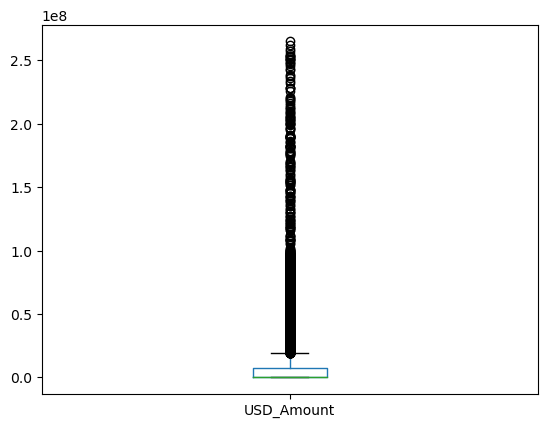

In [25]:
data['USD_Amount'].plot(kind='box')

In [26]:
data['USD_Amount'].describe()

count    1.020000e+04
mean     1.116986e+07
std      2.835851e+07
min      0.000000e+00
25%      1.977600e+04
50%      4.017455e+05
75%      7.711616e+06
max      2.647405e+08
Name: USD_Amount, dtype: float64

In [27]:
print("Maximum Value :",data['USD_Amount'].max())
print()
print("Minimum Value :",data['USD_Amount'].min())

Maximum Value : 264740531

Minimum Value : 0


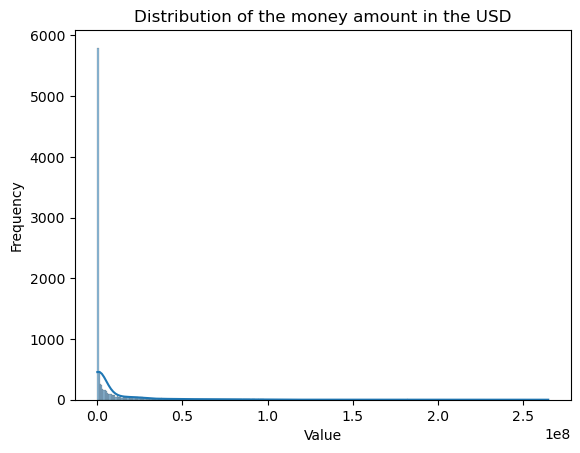

In [28]:
sns.histplot(data['USD_Amount'], kde=True)
plt.title('Distribution of the money amount in the USD')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

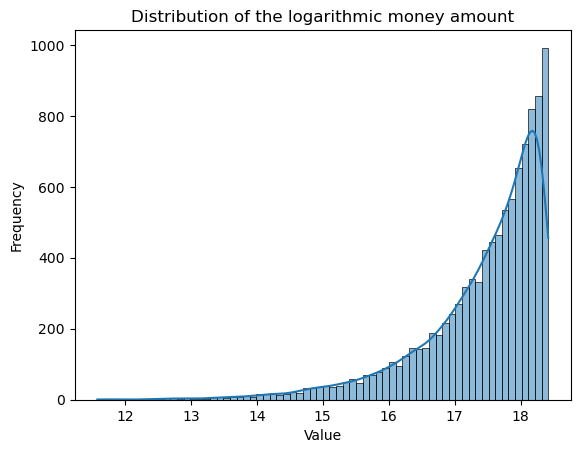

In [29]:
sns.histplot(data['log_amount'], kde=True)
plt.title('Distribution of the logarithmic money amount')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

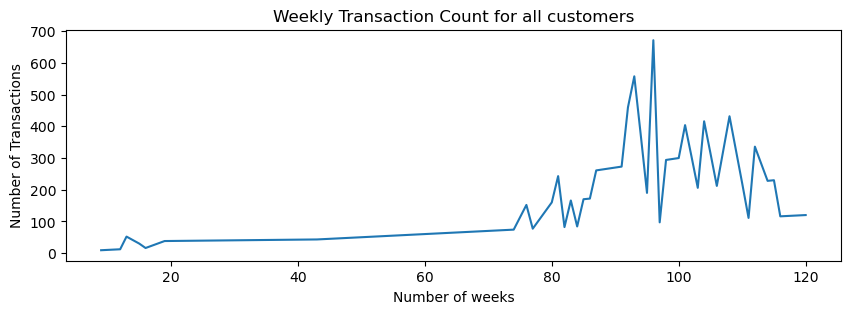

In [30]:
daily_counts = data.groupby('weekly_frequency').size()

plt.figure(figsize=(10, 3))
daily_counts.plot()
plt.xlabel('Number of weeks')
plt.ylabel('Number of Transactions')
plt.title('Weekly Transaction Count for all customers')
plt.show()

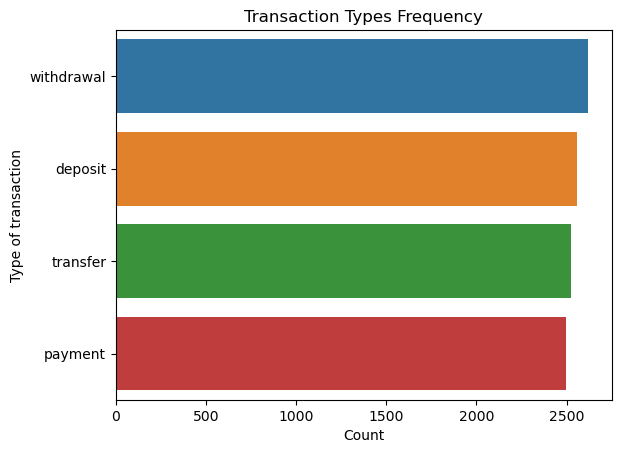

In [31]:
counts = data['type'].value_counts()

sns.barplot(x=counts.values, y=counts.index)
plt.ylabel('Type of transaction')
plt.xlabel('Count')
plt.title('Transaction Types Frequency')
plt.xticks(rotation=0)  
plt.show()

#### Now We gonna identify the transactions outliers and unusual transactions.
###### If they contain intersection transactions then these transactions are surely suspected.

In [32]:
top_3 = data.nlargest(3,'USD_Amount')

print("Top 3 Transactions done : ")
top_3[['recipient_name','country', 'USD_Amount','type','description']]

Top 3 Transactions done : 


,recipient_name,country,USD_Amount,type,description
129,Amanda Richards,Equatorial Guinea,264740531,deposit,extend sticky initiatives
242,Kristy Rodriguez,Tanzania,262018604,transfer,transition next-generation content
158,Patrick Jones,Antarctica (the territory South of 60 deg S),258855079,deposit,drive robust supply-chains


In [33]:
Q1 = data['USD_Amount'].quantile(0.25)
Q3 = data['USD_Amount'].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

outliers_values = data[(data['USD_Amount'] > upper_bound)]

print(f"Detected {len(outliers_values)} Outliers transactions.")

Detected 1654 Outliers transactions.


In [34]:
def identify_outliers_zscore(df, column, threshold=2):
    z_scores = (df[column] - df[column].mean()) / df[column].std()
    outliers = df[abs(z_scores) > threshold]
    return outliers

In [35]:
outliers_zscore = identify_outliers_zscore(data,"USD_Amount")

print(f"Detected {len(outliers_zscore)} unusual transactions :")

outliers_zscore.sample(n=3)

Detected 446 unusual transactions :


,transaction_id,date,type,amount,currency,country,description,recipient_name,Rate,USD_Amount,weekly_frequency,log_amount
6965,8b770a17-32c5-4428-bda9-daa52fd7a8b2,2024-05-13,withdrawal,72832735.0,OMR,Jersey,embrace world-class portals,Michelle Shepard,2.6,189365111,105,18.103676
115,151cd5eb-80ec-495b-8b19-14eacf5f9517,2023-04-05,transfer,82195687.0,CUC,Bahamas,architect visionary convergence,Ricky Bolton,1.0,82195687,93,18.224613
5762,b3dbe731-a49b-4ac7-9ba9-a60776998b5e,2023-10-18,payment,97073689.0,USD,Malta,transform out-of-the-box niches,Brian Tran,1.0,97073689,111,18.390981


In [36]:
high_risk_countries = ['Korea', 'Sudan', 'Angola' ,'Ukraine','Colombia', 'Dominican Republic',
                      'Namibia' ,'Djibouti','Honduras','India','Malawi' ]

In [37]:
def identify_unusual_transactions(df,country_column,money_column, high_risk_countries, threshold_amount):
    suspect_transactions = df[(df[country_column].isin(high_risk_countries)) & (df[money_column] > threshold_amount)]
    return suspect_transactions

In [38]:
unusual=identify_unusual_transactions(data,"country","USD_Amount",high_risk_countries,10000000)

print(f"Detected {len(unusual)} unusual transactions :")
unusual.sample(n=3)

Detected 82 unusual transactions :


,transaction_id,date,type,amount,currency,country,description,recipient_name,Rate,USD_Amount,weekly_frequency,log_amount
6810,25435d2a-7757-41b0-ae00-34b39581e984,2023-10-23,withdrawal,97065041.0,EUR,Namibia,innovate granular mindshare,Richard Burgess,0.92,89299838,94,18.390892
3626,4bb67f4d-3786-42f1-8b21-bd18c991ef09,2023-03-18,withdrawal,78322223.0,FJD,Korea,enhance collaborative technologies,Nathan Long,0.49,38377889,93,18.176342
2961,f661349b-e5cb-4c5c-be20-8203d058fd90,2024-11-11,transfer,97889952.0,MOP,Korea,transform customized relationships,Veronica Ramos,0.12,11746794,85,18.399354


In [39]:
suspected = outliers_zscore.merge(unusual, how='inner')
suspected_transactions = suspected.merge(outliers_values,how ='inner')
print("Detected Fraud Transactions : ")
suspected_transactions[['recipient_name','country', 'USD_Amount','type','description']]

Detected Fraud Transactions : 


,recipient_name,country,USD_Amount,type,description
0,Joshua Jenkins,Korea,75270303,deposit,repurpose bleeding-edge communities
1,Patricia Trujillo,Colombia,216258184,deposit,disintermediate frictionless bandwidth
2,Ronald Clark,Sudan,147161377,payment,embrace granular deliverables
3,Danielle Newman,Djibouti,101518320,deposit,seize holistic synergies
4,Howard Townsend,Angola,188917461,payment,harness real-time mindshare
5,Lisa Meadows,Dominican Republic,79954053,deposit,repurpose wireless e-markets
6,Kevin Conway,Ukraine,86267841,transfer,optimize cross-platform markets
7,Gloria Alexander,Angola,82140604,transfer,transform best-of-breed bandwidth
8,Elizabeth Green,Colombia,80836732,payment,synergize transparent methodologies
9,Leslie Hernandez,Honduras,76305210,deposit,implement magnetic functionalities


In [40]:
suspected_transactions = outliers_zscore.merge(unusual, how='outer')
print("All Suspected Transactions : ")
suspected_transactions[['recipient_name','country', 'USD_Amount','type','description']]

All Suspected Transactions : 


,recipient_name,country,USD_Amount,type,description
0,Robin Conley,Japan,84307982,payment,expedite distributed info-mediaries
1,Kelly Davidson,Israel,76179911,payment,extend efficient architectures
2,William Blevins,Gabon,94409496,transfer,e-enable magnetic e-services
3,Michael French,Equatorial Guinea,94547652,payment,evolve frictionless portals
4,Charles Long,United States of America,97576172,payment,revolutionize B2B platforms
...,...,...,...,...,...
504,Elizabeth Wu,Malawi,24632063,transfer,maximize turn-key niches
505,Anna Rose,Korea,16578779,deposit,engineer one-to-one experiences
506,Lee Allen,Korea,15259172,withdrawal,innovate out-of-the-box web services
507,Collin Patel,Ukraine,42130963,payment,visualize visionary info-mediaries


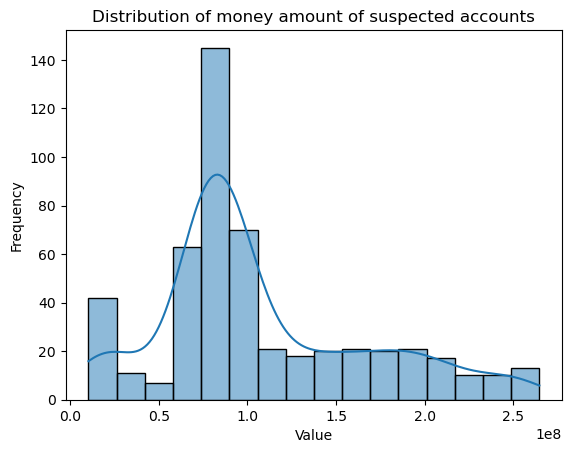

In [41]:
sns.histplot(suspected_transactions['USD_Amount'], kde=True)
plt.title('Distribution of money amount of suspected accounts')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

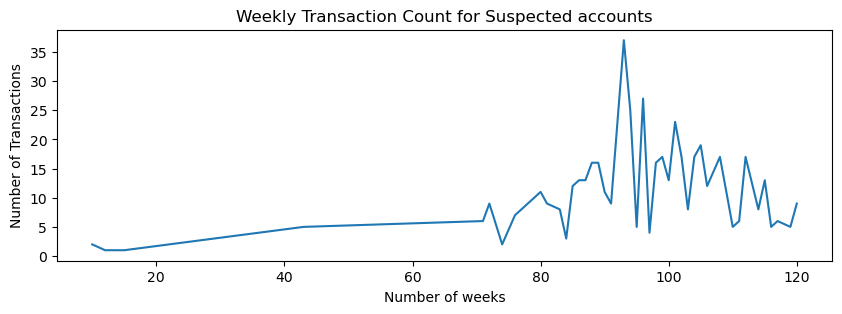

In [42]:
daily_counts = suspected_transactions.groupby('weekly_frequency').size()

plt.figure(figsize=(10, 3))
daily_counts.plot()
plt.xlabel('Number of weeks')
plt.ylabel('Number of Transactions')
plt.title('Weekly Transaction Count for Suspected accounts')
plt.show()

In [43]:
suspected_ids = suspected_transactions['transaction_id'].tolist()

print("Number of suspected transactions :",len(suspected_ids))

Number of suspected transactions : 509


In [44]:
data['high_risk'] = 0
data.loc[data['transaction_id'].isin(suspected_ids), 'high_risk'] = 1

In [45]:
data.sample(n=6)

,transaction_id,date,type,amount,currency,country,description,recipient_name,Rate,USD_Amount,weekly_frequency,log_amount,high_risk
5243,b6c40b84-5dbf-4fdc-8ab7-83309f8569d8,2023-01-25,deposit,84494047.0,IDR,Mexico,strategize frictionless applications,Stacey Parsons,0.00007,5915,87,18.252192,0
2079,828649b6-c397-4b05-888d-1f0801bad881,2023-04-14,payment,17547440.0,KGS,Reunion,innovate cutting-edge web-readiness,David Brown,0.01000,175474,92,16.680419,0
8358,e5cb022a-b406-4848-a2ce-0fe453219c28,2023-10-15,withdrawal,90568827.0,WST,Guyana,orchestrate 24/7 markets,Sarah Bell,0.03000,2717065,120,18.321621,0
7468,4c56e719-b2d0-4158-916b-aa819dc0e7bc,2024-09-20,transfer,99771667.0,BZD,United Kingdom,exploit clicks-and-mortar infrastructures,Abigail Clark,0.50000,49885834,110,18.418395,0
1105,81c054e8-29d9-4a95-ae34-5f93b31665d2,2024-01-20,deposit,89503577.0,GYD,Burundi,visualize value-added communities,Carl Woodard,0.00040,35801,103,18.309789,0
4867,56e71464-151f-4198-96a2-ea221368ac1e,2024-09-11,payment,77308279.0,LKR,Saint Barthelemy,streamline 24/365 partnerships,Kenneth Mcintosh,0.00400,309233,104,18.163312,0


In [46]:
X = data[["USD_Amount","log_amount"]]
y = data["high_risk"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [47]:
model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy = ", round(accuracy*100,2),"%")

Accuracy =  94.74 %


In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      2899
           1       0.00      0.00      0.00       161

    accuracy                           0.95      3060
   macro avg       0.47      0.50      0.49      3060
weighted avg       0.90      0.95      0.92      3060



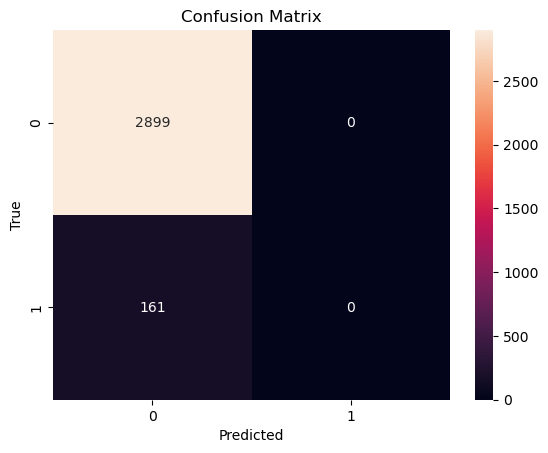

In [49]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [50]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)